In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer.pitch import Pitch

In [68]:
## reading the messi passing data (betis game)
df = pd.read_csv('messibetis.csv')

In [69]:
## dispaying the game data
df

,player,minute,second,x,y,type,outcome,endX,endY
0,messi,45,0,50,50,Pass,Successful,40,43
1,messi,45,25,63,48,Pass,Successful,75,83
2,messi,46,4,74,58,Pass,Successful,71,65
3,messi,46,7,76,68,Pass,Successful,95,78
4,messi,46,55,100,1,Pass,Unsuccessful,96,38
5,messi,47,42,73,25,Pass,Successful,70,54
6,messi,49,47,75,43,Pass,Unsuccessful,82,38
7,messi,50,10,79,31,Pass,Successful,87,24
8,messi,50,17,82,52,Pass,Successful,93,68
9,messi,50,24,98,62,Pass,Unsuccessful,98,61


In [70]:
## Converting the x axis from 80 to 120, as that is what the fields dimensions are, however the data points are 100x100
df['x'] = df['x']*1.2
## converting the y axis from 100 --> 80
df ['y'] = df['y']*0.8

## Same changes to the endXY, (end is where the pass ends up, so same thing applies)
df ['endX'] = df['endX']*1.2
df ['endY'] = df['endY']*0.8


In [71]:
#to check if the values actually changed (they did)
df

,player,minute,second,x,y,type,outcome,endX,endY
0,messi,45,0,60.0,40.0,Pass,Successful,48.0,34.4
1,messi,45,25,75.6,38.4,Pass,Successful,90.0,66.4
2,messi,46,4,88.8,46.4,Pass,Successful,85.2,52.0
3,messi,46,7,91.2,54.4,Pass,Successful,114.0,62.4
4,messi,46,55,120.0,0.8,Pass,Unsuccessful,115.2,30.4
5,messi,47,42,87.6,20.0,Pass,Successful,84.0,43.2
6,messi,49,47,90.0,34.4,Pass,Unsuccessful,98.4,30.4
7,messi,50,10,94.8,24.8,Pass,Successful,104.4,19.2
8,messi,50,17,98.4,41.6,Pass,Successful,111.6,54.4
9,messi,50,24,117.6,49.6,Pass,Unsuccessful,117.6,48.8


Text(0.5, 1.0, 'Messi Pass Map vs Real Betis 2022-23 Season')

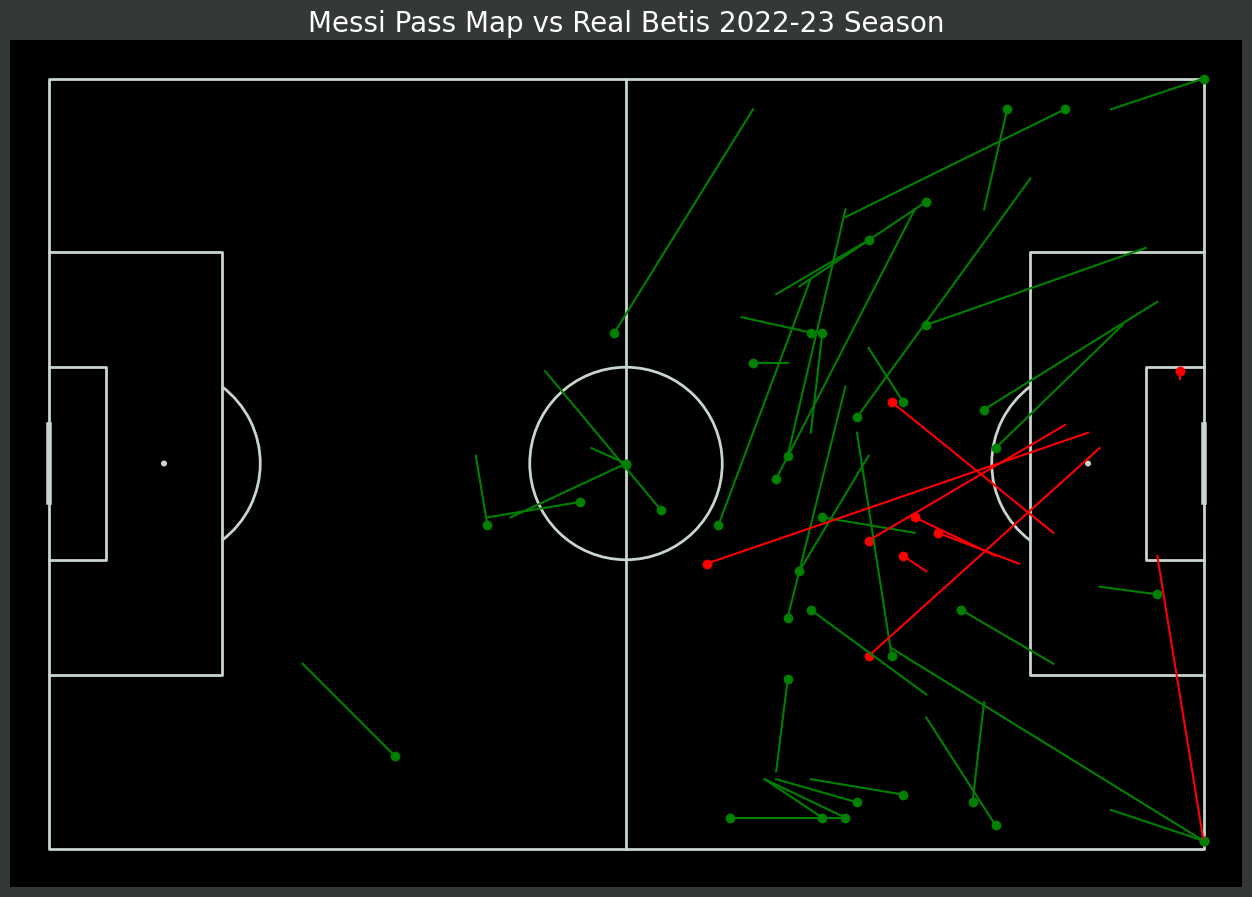

In [94]:


## setting up/creating the field
pitch = Pitch(pitch_type='statsbomb', pitch_color='#000000', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor('#353935')

##Draw the pitch on the ax figure as well as invert the axis for this specific pitch
plt.gca().invert_yaxis()

## a for loop that scans through our csv data files, goes over the x y coordinates, for start and end passes, and plots a line depending on if the pas was successful or not
for x in range(len(df['x'])):
    if df['outcome'][x] == 'Successful':
        plt.plot((df['x'][x],df['endX'][x]),(df['y'][x],df['endY'][x]),color='green')
        plt.scatter(df['x'][x],df['y'][x],color='green')
    if df['outcome'][x] == 'Unsuccessful':
        plt.plot((df['x'][x],df['endX'][x]),(df['y'][x],df['endY'][x]),color='red')
        plt.scatter(df['x'][x],df['y'][x],color='red')

plt.title('Messi Pass Map vs Real Betis 2022-23 Season' ,color='white',size=20)
